In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define state space dimensions
B_STATES = 5 # for B = 0, 1, 2, 3, 4
W_STATES = 5 # for W = 0, 1, 2
C_STATES = 3 # for C = 0, 1, 2, 3, 4

# Total number of regular states
NUM_REGULAR_STATES = B_STATES * W_STATES * C_STATES # 5 * 3 * 5 = 75

# Total number of states including the failure state (index 75)
NUM_TOTAL_STATES = NUM_REGULAR_STATES + 1 # 75 + 1 = 76

# Number of actions
NUM_ACTIONS = 3

# Define action indices
AC = 0 # Action Charge
AS = 1 # Action Solar
AE = 2 # Action Export


def factors_to_state(b, w, c):
    """
    Converts (b, w, c) factors to a unique state index.
    Raises ValueError if factors are outside defined ranges.
    """
    if not (0 <= b < B_STATES and 0 <= w < W_STATES and 0 <= c < C_STATES):
        raise ValueError(f"Invalid factors: b={b}, w={w}, c={c} must be within defined space dimensions.")
        
    return b * (W_STATES * C_STATES) + w * C_STATES + c

def state_to_factors(state_index):
    """
    Converts a state index to (b, w, c) factors.
    Handles the failure state (index NUM_REGULAR_STATES) by returning (-1, -1, -1).
    Raises ValueError for invalid regular state indices.
    """
    if state_index == NUM_REGULAR_STATES: # State 75 is the failure state
        return (-1, -1, -1) # Indicating a non-factorable failure state
    
    if not (0 <= state_index < NUM_REGULAR_STATES):
        raise ValueError(f"Invalid state_index: {state_index}. Must be between 0 and {NUM_TOTAL_STATES}")
        
    b = state_index // (W_STATES * C_STATES)
    remaining_index = state_index % (W_STATES * C_STATES)
    w = remaining_index // C_STATES
    c = remaining_index % C_STATES
    return (b, w, c)

def create_complex_transition_matrix():
    """
    Creates and populates the 3D transition tensor (T) with probabilistic transitions.
    T has shape (NUM_ACTIONS, NUM_TOTAL_STATES, NUM_TOTAL_STATES).
    """
    T = np.zeros((NUM_ACTIONS, NUM_TOTAL_STATES, NUM_TOTAL_STATES))
    failure_state_index = NUM_TOTAL_STATES - 1
    
    # Weather Transition Matrix P(W_next | W_current)
    # P_W[W_current, W_next]
    P_W = np.zeros((W_STATES, W_STATES))
    P_W[0, 1] = 0.3
    P_W[0, 0] = 0.7
    P_W[1, 2] = 0.4
    P_W[1, 0] = 0.3
    P_W[1, 1] = 0.3
    P_W[2, 3] = 0.4
    P_W[2, 2] = 0.3
    P_W[2, 1] = 0.3
    P_W[3, 4] = 0.4
    P_W[3, 3] = 0.3
    P_W[3, 2] = 0.3
    P_W[4, 4] = 0.7
    P_W[4, 3] = 0.3
    
    # Consumption Probability Function P(C_next | W_next)
    def get_prob_c_next(c_next_val, w_next_val):
        if w_next_val in [0, 1]: # If W_next is 1 or 2, C uniform over [1, 2, 3, 4]
            if c_next_val >= 1 and c_next_val <= 2:
                return 0.5
            else:
                return 0.0
        elif w_next_val == 2: # If W_next is 0, C uniform over [0, 1, 2]
            if c_next_val >= 0 and c_next_val <= 2:
                return 1 / 3
            else:
                return 0.0
        else:  # w_next_val in [3, 4]
            if c_next_val >= 0 and c_next_val <= 1:
                return 0.5
            else:
                return 0.0

    # Failure state transitions to itself for all actions with probability 1
    for action_idx in range(NUM_ACTIONS):
        T[action_idx, failure_state_index, failure_state_index] = 1.0

    # Populate transitions for regular states (0 to NUM_REGULAR_STATES - 1)
    for s_current in range(NUM_REGULAR_STATES):
        b_current, w_current, c_current = state_to_factors(s_current)

        # --- Handle Action 0 (Charge) ---
        action_idx = AC

        # Calculate deterministic B_next for normal charge outcome
        b_next_AC_normal = min(max(b_current - c_current, 0) + 1, B_STATES - 1)

        # Distribute the remaining probability (1 - prob_failure_AC) over possible W_next and C_next
        for w_next_val in range(W_STATES):
            for c_next_val in range(C_STATES):
                prob_w_c_transition = P_W[w_current, w_next_val] * get_prob_c_next(c_next_val, w_next_val)
                
                if prob_w_c_transition > 0:
                    s_next = factors_to_state(b_next_AC_normal, w_next_val, c_next_val)
                    T[action_idx, s_current, s_next] += prob_w_c_transition


        # --- Handle Action 1 (Solar - AS) ---
        action_idx = AS
        failure_prob_AS = 0.0
        
        # Determine charging probability based on current weather
        charge_prob_AS = 0.0
        
        if w_current == 4:
            charge_prob_AS = 0.95
        elif w_current == 3:
            charge_prob_AS = 0.8
        elif w_current == 2:
            charge_prob_AS = 0.5
        elif w_current == 1:
            charge_prob_AS = 0.2
        elif w_current == 0:
            charge_prob_AS = 0.05
            failure_prob_AS = 0.02

        # Calculate deterministic B_next for charged and uncharged outcomes
        b_next_AS_uncharged = max(b_current - c_current, 0)
        b_next_AS_charged = min(b_next_AS_uncharged + 1, B_STATES - 1)

        # Distribute probabilities over possible W_next and C_next for both outcomes
        for w_next_val in range(W_STATES):
            for c_next_val in range(C_STATES):
                prob_w_c_transition = P_W[w_current, w_next_val] * get_prob_c_next(c_next_val, w_next_val)
                
                if prob_w_c_transition > 0:
                    # Add probability for the 'charged' outcome
                    s_next_charged = factors_to_state(b_next_AS_charged, w_next_val, c_next_val)
                    T[action_idx, s_current, s_next_charged] += charge_prob_AS * prob_w_c_transition

                    # Add probability for the 'uncharged' outcome
                    s_next_uncharged = factors_to_state(b_next_AS_uncharged, w_next_val, c_next_val)
                    T[action_idx, s_current, s_next_uncharged] += (1 - charge_prob_AS - failure_prob_AS) * prob_w_c_transition

                    # Add probability for the 'failure' outcome
                    T[action_idx, s_current, failure_state_index] += failure_prob_AS * prob_w_c_transition


        # --- Handle Action 2 (Export - AE) ---
        action_idx = AE
        failure_prob_AE = 0.0
        
        # Calculate deterministic B_next based on current B and C
        b_next_AE = max(b_current - c_current - 1, 0)

        if b_next_AE == 0:
            failure_prob_AE = 0.05

        T[action_idx, s_current, failure_state_index] += failure_prob_AE

        # Distribute probabilities over possible W_next and C_next
        for w_next_val in range(W_STATES):
            for c_next_val in range(C_STATES):
                prob_w_c_transition = P_W[w_current, w_next_val] * get_prob_c_next(c_next_val, w_next_val) * (1 - failure_prob_AE)
                
                if prob_w_c_transition > 0:
                    s_next = factors_to_state(int(b_next_AE), w_next_val, c_next_val)
                    T[action_idx, s_current, s_next] += prob_w_c_transition
                    

    for a in range(T.shape[0]):
        for s in range(T.shape[1]):
            assert np.all(np.isclose(T[a, s].sum(), 1.0)), (s, a, T[a, s].sum())
            
    return T


In [2]:
# --- Main execution --- 
# Create the complex transition matrix
T_complex = create_complex_transition_matrix()

def print_transition_examples(action_idx, action_name, max_initial_states_to_show=5, max_transitions_per_initial_state=3):
    print(f"\n--- Examples for Action {action_idx} ({action_name}) ---")
    
    # Define some interesting example states (b, w, c) to showcase different scenarios
    example_states = [
        (0, 0, 0),   # Low battery, no sun, no consumption
        (4, 2, 0),   # Full battery, sunny, no consumption
        (1, 4, 0),   # Low battery, no sun, high consumption (potential for 0 battery)
        (3, 1, 2),   # Medium battery, cloudy, medium consumption
        (0, 4, 2)    # Empty battery, sunny, high consumption (challenging state)
    ]
    
    states_shown_count = 0
    
    for b_cur, w_cur, c_cur in example_states:
        if states_shown_count >= max_initial_states_to_show:
            break
            
        s_current = factors_to_state(b_cur, w_cur, c_cur)
        print(f"  From Initial State {s_current} ({b_cur},{w_cur},{c_cur}):")
        transitions_for_state = []
        
        for s_next in range(NUM_TOTAL_STATES):
            prob = T_complex[action_idx, s_current, s_next]
            
            if prob > 0:
                transitions_for_state.append((prob, s_next))

        # Sort by probability descending
        transitions_for_state.sort(key=lambda x: x[0], reverse=True)
        transitions_printed_for_this_state = 0
        
        for prob, s_next in transitions_for_state:
            if transitions_printed_for_this_state >= max_transitions_per_initial_state:
                break
            
            if s_next == NUM_TOTAL_STATES - 1: # Failure state
                print(f"    to Failure State {s_next} with P = {prob:.4f}")
            else:
                b_next, w_next, c_next = state_to_factors(s_next)
                print(f"    to State {s_next} ({b_next},{w_next},{c_next}) with P = {prob:.4f}")
                
            transitions_printed_for_this_state += 1
        
        if transitions_printed_for_this_state == 0:
            print("    No transitions with P > 0 found (this should not happen for valid MDPs unless states are terminal).")
            
        states_shown_count += 1

# Print examples for each action
print_transition_examples(AC, "Charge", max_initial_states_to_show=5, max_transitions_per_initial_state=3)
print_transition_examples(AS, "Solar", max_initial_states_to_show=5, max_transitions_per_initial_state=3)
print_transition_examples(AE, "Export", max_initial_states_to_show=5, max_transitions_per_initial_state=3)

# Demonstrate state conversion functions with examples (unchanged from before)
print("\n--- Demonstrating state conversion functions (unchanged) ---")
print(f"Factors (0, 0, 0) -> State: {factors_to_state(0, 0, 0)}")
print(f"Factors (4, 4, 2) -> State: {factors_to_state(4, 4, 2)}") # Max regular state
print(f"State 0 -> Factors: {state_to_factors(0)}")
print(f"State 74 -> Factors: {state_to_factors(74)}") # Max regular state
print(f"State 75 (Failure) -> Factors: {state_to_factors(75)}") # Failure state


--- Examples for Action 0 (Charge) ---
  From Initial State 0 (0,0,0):
    to State 16 (1,0,1) with P = 0.3500
    to State 17 (1,0,2) with P = 0.3500
    to State 19 (1,1,1) with P = 0.1500
  From Initial State 66 (4,2,0):
    to State 69 (4,3,0) with P = 0.2000
    to State 70 (4,3,1) with P = 0.2000
    to State 64 (4,1,1) with P = 0.1500
  From Initial State 27 (1,4,0):
    to State 42 (2,4,0) with P = 0.3500
    to State 43 (2,4,1) with P = 0.3500
    to State 39 (2,3,0) with P = 0.1500
  From Initial State 50 (3,1,2):
    to State 31 (2,0,1) with P = 0.1500
    to State 32 (2,0,2) with P = 0.1500
    to State 34 (2,1,1) with P = 0.1500
  From Initial State 14 (0,4,2):
    to State 27 (1,4,0) with P = 0.3500
    to State 28 (1,4,1) with P = 0.3500
    to State 24 (1,3,0) with P = 0.1500

--- Examples for Action 1 (Solar) ---
  From Initial State 0 (0,0,0):
    to State 1 (0,0,1) with P = 0.3255
    to State 2 (0,0,2) with P = 0.3255
    to State 4 (0,1,1) with P = 0.1395
  From I

In [3]:
# Questão 2.

def create_cost_matrix():
    C = np.zeros((NUM_TOTAL_STATES, NUM_ACTIONS))
    
    for s in range(NUM_TOTAL_STATES):
        if s == 75:
            C[s, :] = 500
        else:
            b, w, c = state_to_factors(s)
            
            C[s, AC] = 10
            C[s, AS] = 0
            
            if b > c:
                C[s, AE] = -5
            else:
                C[s, AE] = 0
    return C

In [4]:
def value_iteration(T, C, gamma, epsilon=1e-6):
    num_states = T.shape[1]
    num_actions = T.shape[0]
    V = np.zeros(num_states)
    iterations = 0
    errors = []
    
    while True:
        V_old = V.copy()
        
        Q = np.zeros((num_states, num_actions))
        
        for a in range(num_actions):
            Q[:, a] = C[:, a] + gamma * T[a] @ V_old
        
        V = np.min(Q, axis=1) 
        
        error = np.max(np.abs(V - V_old))
        errors.append(error)
        iterations += 1
        
        if error < epsilon:
            break

    policy = np.argmin(Q, axis=1)
    
    return V, policy, iterations, errors

In [5]:
def policy_iteration(T, C, gamma, eps=1e-6):
    num_states = T.shape[1]
    num_actions = T.shape[0]
    
    # Initialize policy with uniform policy
    policy = np.ones((num_states, num_actions)) / num_actions
    quit = False
    iterations = 0
    errors = []
    V = np.zeros((num_states, 1))

    while not quit:
        V_old = V.copy()
        
        # --- POLICY EVALUATION ---
        cpi = np.sum(C * policy, axis=1, keepdims=True)
        Ppi = np.zeros((num_states, num_states))
        for a in range(num_actions):
            Ppi += policy[:, a, None] * T[a]

        V = np.linalg.solve(np.eye(num_states) - gamma * Ppi, cpi)
        
        error = np.max(np.abs(V - V_old))
        errors.append(error)

        # --- COMPUTE Q-VALUES ---
        Q = np.zeros((num_states, num_actions))
        for a in range(num_actions):
            Q[:, a, None] = C[:, a, None] + gamma * T[a].dot(V)

        # --- COMPUTE GREEDY POLICY ---
        Qmin = np.min(Q, axis=1, keepdims=True)
        
        pnew = np.isclose(Q, Qmin, atol=eps, rtol=eps).astype(float)
        pnew = pnew / pnew.sum(axis=1, keepdims=True)

        # Compute stopping condition
        quit = np.allclose(policy, pnew)

        # Update
        policy = pnew
        iterations += 1

    return V.flatten(), policy, iterations, errors

<>:15: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:15: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/tmp/ipykernel_3752283/1445868426.py:15: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.ylabel('Bellman Error ($||V_{k+1} - V_k||_\infty$)')


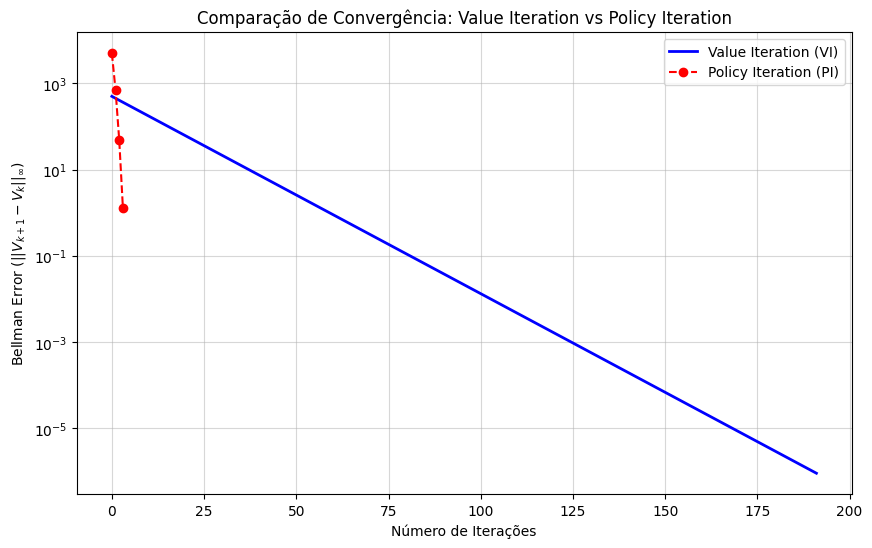

Cost-to-go Value Iteration: [ 4.04205229e+01  4.04205229e+01  4.04205229e+01  1.83540500e+01
  1.83540500e+01  1.83540500e+01  6.96357013e+00  6.96357013e+00
  6.96357013e+00  9.19970346e-01  9.19970346e-01  9.19970346e-01
 -1.74658280e+00 -1.74658280e+00 -1.74658280e+00  4.03771914e+01
  4.04205229e+01  4.04205229e+01  1.81341827e+01  1.83540500e+01
  1.83540500e+01  6.04815468e+00  6.96357013e+00  6.96357013e+00
 -8.82062076e-01  9.19970346e-01  9.19970346e-01 -3.96384919e+00
 -1.74658280e+00 -1.74658280e+00  2.54205229e+01  4.03771914e+01
  4.04205229e+01  1.32661701e+01  1.81341827e+01  1.83540500e+01
  1.76019352e+00  6.04815468e+00  6.96357013e+00 -4.22498360e+00
 -8.82062076e-01  9.19970346e-01 -6.79366846e+00 -3.96384919e+00
 -1.74658280e+00  2.53771914e+01  2.54205229e+01  4.03771914e+01
  1.26062330e+01  1.32661701e+01  1.81341827e+01  3.36115830e-01
  1.76019352e+00  6.04815468e+00 -6.29633170e+00 -4.22498360e+00
 -8.82062076e-01 -9.07806923e+00 -6.79366846e+00 -3.96384919e+

In [6]:
# plot da comparação de convergência

C_matrix = create_cost_matrix()

V_vi, pol_vi, iter_vi, err_vi = value_iteration(T_complex, C_matrix, gamma=0.9)
V_pi, pol_pi, iter_pi, err_pi = policy_iteration(T_complex, C_matrix, gamma=0.9)

# Criar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(err_vi, label='Value Iteration (VI)', color='blue', linewidth=2)
plt.plot(err_pi, label='Policy Iteration (PI)', color='red', marker='o', linestyle='--')

plt.yscale('log') # Escala logarítmica para ver bem a convergência
plt.xlabel('Número de Iterações')
plt.ylabel('Bellman Error ($||V_{k+1} - V_k||_\infty$)')
plt.title('Comparação de Convergência: Value Iteration vs Policy Iteration')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

print(f"Cost-to-go Value Iteration: {V_vi}")
print(f"Cost-to-go Policy Iteration: {V_pi}")
print(f"Policy Value Iteration: {pol_vi}")
print(f"Policy Policy Iteration: {pol_pi}")
print(f"Nr iterations Value Iteration: {iter_vi}")
print(f"Nr iterations Policy Iteration: {iter_pi}")
print(f"Error Value Iteration: {err_vi}")
print(f"Error Policy Iteration: {err_pi}")

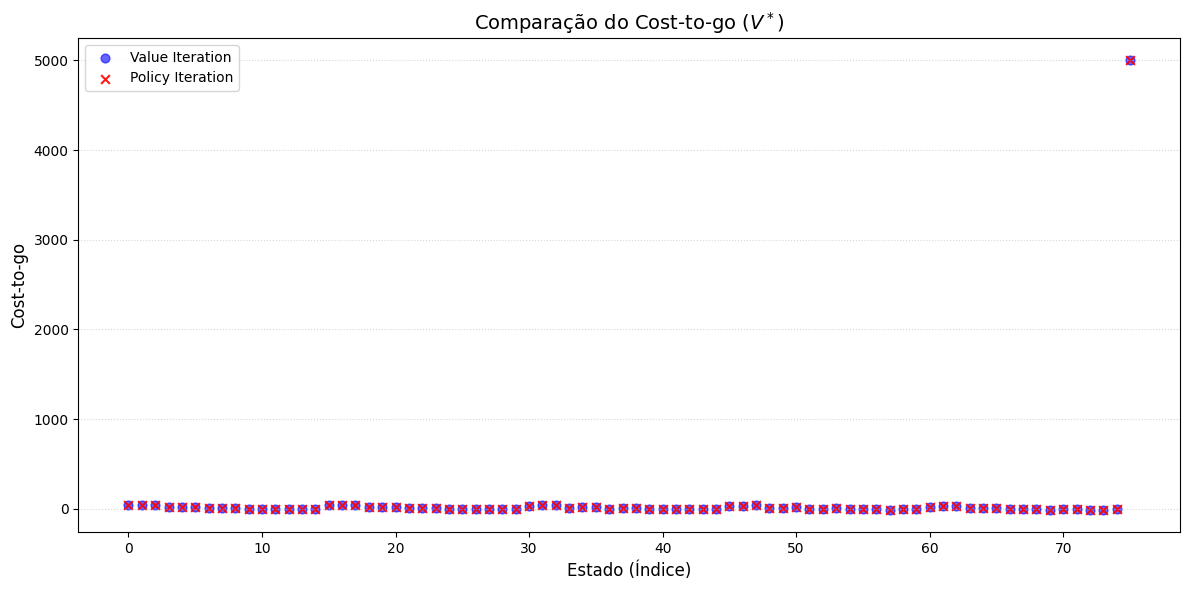

In [7]:
# Plot da comparação do cost-to-go

states = range(len(V_vi))

plt.figure(figsize=(12, 6))

plt.scatter(states, V_vi, label='Value Iteration', color='blue', 
            marker='o', s=40, alpha=0.6)

plt.scatter(states, V_pi, label='Policy Iteration', color='red', 
            marker='x', s=40, alpha=0.9)

plt.title('Comparação do Cost-to-go ($V^*$)', fontsize=14)
plt.xlabel('Estado (Índice)', fontsize=12)
plt.ylabel('Cost-to-go', fontsize=12)
plt.legend()
plt.grid(True, axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


In [8]:
# Exercicio 3

def create_custom_cost_matrix(cost_ac=10, cost_ae=-5, r_fail=500):
    C = np.zeros((NUM_TOTAL_STATES, NUM_ACTIONS))
    
    for s in range(NUM_TOTAL_STATES):
        if s == 75:
            C[s, :] = r_fail
        else:
            b, w, c = state_to_factors(s)
            
            C[s, AC] = cost_ac
            C[s, AS] = 0
            
            if b > c:
                C[s, AE] = cost_ae
            else:
                C[s, AE] = 0
    return C


                         FUNÇÕES DE CUSTO IMPLEMENTADAS                         
Cenário                        | 0    | 5    | 32   | 49   | 75  
--------------------------------------------------------------------------------
Base                           |   10 |    0 |   10 |   -5 |  500
Grande penalização de falha    |   10 |    0 |   10 |   -5 | 50000
Exportação muito lucrativa     |   10 |   10 |   10 | -500 |  500
Energia de rede muito cara     |    0 |    0 |    0 |   -5 |  500

                           COMPARAÇÃO DE NR ITERAÇÕES                           
Cenário                        | It. Total  | It. < 0.1 
------------------------------------------------------------
Base                           | 192        | 81        
Grande penalização de falha    | 235        | 125       
Exportação muito lucrativa     | 192        | 81        
Energia de rede muito cara     | 192        | 81        

                            COMPARAÇÃO DE POLÍTICAS                          

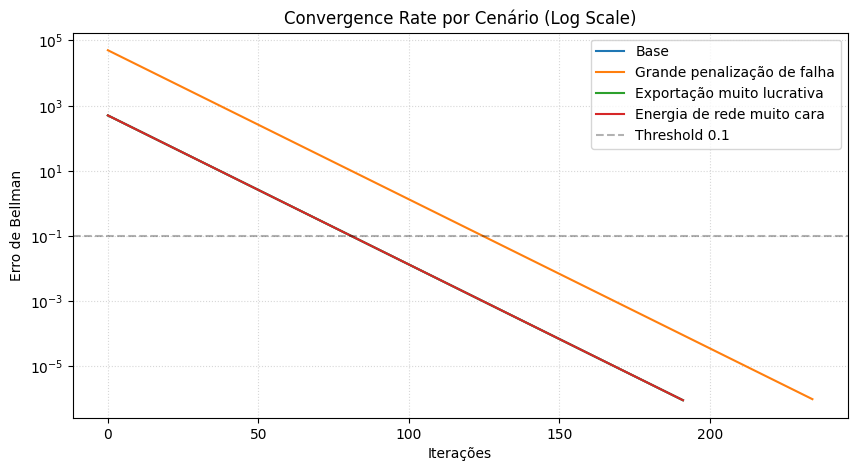

In [9]:
THRESHOLD = 0.1

cenarios = [
    ("Base", 10, -5, 500),
    ("Grande penalização de falha", 10, -5, 50000),
    ("Exportação muito lucrativa", 10, -500, 500),
    ("Energia de rede muito cara", 1000, -5, 500),
]

estados_analise = [0, 5, 32, 49, 75]
resultados = {}

for nome, c_ac, c_ae, r_f in cenarios:
    C_temp = create_custom_cost_matrix(cost_ac=c_ac, cost_ae=c_ae, r_fail=r_f)
    V, pol, it_final, errors = value_iteration(T_complex, C_temp, gamma=0.9)
    
    it_threshold = next((i for i, e in enumerate(errors) if e < THRESHOLD), it_final)
    
    resultados[nome] = {
        'V': V, 'politica': pol, 'it_final': it_final, 
        'it_threshold': it_threshold, 'errors': errors, 'custos': C_temp
    }

print("\n" + "="*80)
print(f"{'FUNÇÕES DE CUSTO IMPLEMENTADAS':^80}")
print("="*80)
header = f"{'Cenário':<30} | " + " | ".join([f"{s:<3} " for s in estados_analise])
print(header)

print("-" * 80)

for nome, data in resultados.items():
    custos_decididos = [data['custos'][s, data['politica'][s]] for s in estados_analise]
    custos_str = " | ".join([f"{c:>4.0f}" for c in custos_decididos])
    print(f"{nome:<30} | {custos_str}")

print("\n" + "="*80)
print(f"{'COMPARAÇÃO DE NR ITERAÇÕES':^80}")
print("="*80)
print(f"{'Cenário':<30} | {'It. Total':<10} | {'It. < 0.1':<10}")
print("-" * 60)
for nome, data in resultados.items():
    print(f"{nome:<30} | {data['it_final']:<10} | {data['it_threshold']:<10}")


print("\n" + "="*80)
print(f"{'COMPARAÇÃO DE POLÍTICAS':^80}")
print("="*80)
base_name = "Base"
base_policy = resultados[base_name]['politica']

print(f"{'Cenário':<30} | {'Diferenças (nº estados)':<25} | {'Similaridade (%)':<15}")
print("-" * 80)

for nome, data in resultados.items():
    current_policy = data['politica']
    diferencas = np.sum(current_policy != base_policy)
    similaridade = (1 - (diferencas / NUM_TOTAL_STATES)) * 100
    
    print(f"{nome:<30} | {diferencas:<25} | {similaridade:>13.1f}%")



plt.figure(figsize=(10, 5))
for nome, data in resultados.items():
    plt.semilogy(data['errors'], label=nome)
plt.axhline(y=THRESHOLD, color='black', linestyle='--', alpha=0.3, label='Threshold 0.1')
plt.title('Convergence Rate por Cenário (Log Scale)')
plt.xlabel('Iterações')
plt.ylabel('Erro de Bellman')
plt.legend()
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.show()


In [10]:
def create_marginalized_transition_matrix():
    NUM_REGULAR_MARGINAL = B_STATES * C_STATES
    NUM_TOTAL_MARGINAL = NUM_REGULAR_MARGINAL + 1
    T_marg = np.zeros((NUM_ACTIONS, NUM_TOTAL_MARGINAL, NUM_TOTAL_MARGINAL))
    

    P_W = np.zeros((W_STATES, W_STATES))
    P_W[0, 1], P_W[0, 0] = 0.3, 0.7
    P_W[1, 2], P_W[1, 0], P_W[1, 1] = 0.4, 0.3, 0.3
    P_W[2, 3], P_W[2, 2], P_W[2, 1] = 0.4, 0.3, 0.3
    P_W[3, 4], P_W[3, 3], P_W[3, 2] = 0.4, 0.3, 0.3
    P_W[4, 4], P_W[4, 3] = 0.7, 0.3

    # pi * P = pi
    vals, vecs = np.linalg.eig(P_W.T)
    stationary_w = np.real(vecs[:, np.isclose(vals, 1)].flatten())
    stationary_w /= stationary_w.sum()


    def factors_to_state_marg(b, c):
        return b * C_STATES + c


    p_charge_list = [0.05, 0.2, 0.5, 0.8, 0.95]
    p_charge_avg = sum(p_charge_list[w] * stationary_w[w] for w in range(W_STATES))
    
    p_fail_as_avg = stationary_w[0] * 0.02

    prob_c_next_avg = np.zeros(C_STATES)
    for w_next in range(W_STATES):
        for c_next in range(C_STATES):
            if w_next in [0, 1] and c_next in [1, 2]: prob_c_next_avg[c_next] += stationary_w[w_next] * 0.5
            elif w_next == 2 and c_next in [0, 1, 2]: prob_c_next_avg[c_next] += stationary_w[w_next] * (1/3)
            elif w_next in [3, 4] and c_next in [0, 1]: prob_c_next_avg[c_next] += stationary_w[w_next] * 0.5

    fail_idx = NUM_TOTAL_MARGINAL - 1
    for a in range(NUM_ACTIONS):
        T_marg[a, fail_idx, fail_idx] = 1.0

    for b in range(B_STATES):
        for c in range(C_STATES):
            s_curr = factors_to_state_marg(b, c)
            
            # --- Ação AC (Charge) ---
            b_next = min(max(b - c, 0) + 1, B_STATES - 1)
            for c_next in range(C_STATES):
                T_marg[AC, s_curr, factors_to_state_marg(b_next, c_next)] += prob_c_next_avg[c_next]

            # --- Ação AS (Solar) ---
            b_uncharged = max(b - c, 0)
            b_charged = min(b_uncharged + 1, B_STATES - 1)
            
            T_marg[AS, s_curr, fail_idx] += p_fail_as_avg
            for c_next in range(C_STATES):
                p_trans = prob_c_next_avg[c_next]
                T_marg[AS, s_curr, factors_to_state_marg(b_charged, c_next)] += p_charge_avg * p_trans
                T_marg[AS, s_curr, factors_to_state_marg(b_uncharged, c_next)] += (1 - p_charge_avg - p_fail_as_avg) * p_trans

            # --- Ação AE (Export) ---
            b_next_ae = max(b - c - 1, 0)
            p_fail_ae = 0.05 if b_next_ae == 0 else 0
            T_marg[AE, s_curr, fail_idx] += p_fail_ae
            for c_next in range(C_STATES):
                T_marg[AE, s_curr, factors_to_state_marg(int(b_next_ae), c_next)] += (1 - p_fail_ae) * prob_c_next_avg[c_next]

    return T_marg

In [11]:
def state_to_factors_marginalized(state_index):
    NUM_REGULAR_MARGINAL = 15
    
    if state_index == NUM_REGULAR_MARGINAL:
        return (-1, -1)
    
    if not (0 <= state_index < NUM_REGULAR_MARGINAL):
        raise ValueError(f"Índice inválido: {state_index}. Deve estar entre 0 e 15.")
    
    b = state_index // 3
    c = state_index % 3
    return (b, c)


In [12]:
def create_cost_matrix_marginalized():
    num_states_marg = 16 
    C = np.zeros((num_states_marg, 3))
    
    for s in range(num_states_marg):
        if s == 15:
            C[s, :] = 500
        else:
            b, c = state_to_factors_marginalized(s)
            
            C[s, AC] = 10
            C[s, AS] = 0
            
            if b > c:
                C[s, AE] = -5
            else:
                C[s, AE] = 0
    return C

<>:15: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:15: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/tmp/ipykernel_3752283/1410347159.py:15: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  plt.ylabel('Bellman Error ($||V_{k+1} - V_k||_\infty$)')


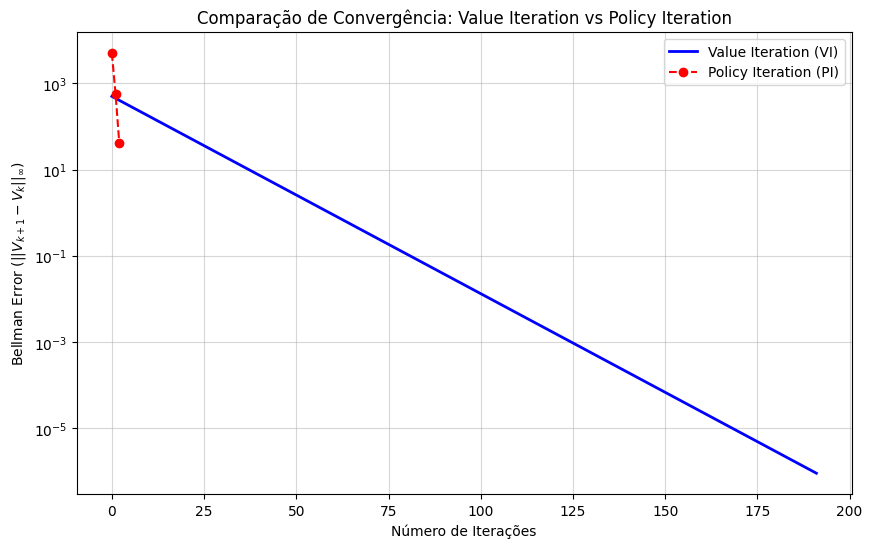

Cost-to-go Value Iteration: [  84.34852349   84.34852349   84.34852349   79.18251336   84.34852349
   84.34852349   69.34852349   79.18251336   84.34852349   64.18251336
   69.34852349   79.18251336   57.55730094   64.18251336   69.34852349
 4999.99999181]
Cost-to-go Policy Iteration: [  84.34852377   84.34852377   84.34852377   79.18251364   84.34852377
   84.34852377   69.34852377   79.18251364   84.34852377   64.18251364
   69.34852377   79.18251364   57.55730121   64.18251364   69.34852377
 5000.        ]
Policy Value Iteration: [0 0 0 0 0 0 2 0 0 2 2 0 2 2 2 0]
Policy Policy Iteration: [[1.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         0.         1.        ]
 [1.         0.         0.        ]
 [1.         0.         0.        ]
 [0.         0.         1.        ]
 [0.         0.         1.        ]
 [1.  

In [14]:
T_marg = create_marginalized_transition_matrix()

C_matrix_marg = create_cost_matrix_marginalized()

V_vi, pol_vi, iter_vi, err_vi = value_iteration(T_marg, C_matrix_marg, gamma=0.9)
V_pi, pol_pi, iter_pi, err_pi = policy_iteration(T_marg, C_matrix_marg, gamma=0.9)

# Criar o gráfico
plt.figure(figsize=(10, 6))
plt.plot(err_vi, label='Value Iteration (VI)', color='blue', linewidth=2)
plt.plot(err_pi, label='Policy Iteration (PI)', color='red', marker='o', linestyle='--')

plt.yscale('log') # Escala logarítmica para ver bem a convergência
plt.xlabel('Número de Iterações')
plt.ylabel('Bellman Error ($||V_{k+1} - V_k||_\infty$)')
plt.title('Comparação de Convergência: Value Iteration vs Policy Iteration')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

print(f"Cost-to-go Value Iteration: {V_vi}")
print(f"Cost-to-go Policy Iteration: {V_pi}")
print(f"Policy Value Iteration: {pol_vi}")
print(f"Policy Policy Iteration: {pol_pi}")
print(f"Nr iterations Value Iteration: {iter_vi}")
print(f"Nr iterations Policy Iteration: {iter_pi}")
print(f"Error Value Iteration: {err_vi}")
print(f"Error Policy Iteration: {err_pi}")